<a href="https://colab.research.google.com/github/GildasTaliah/ML-In-Finance/blob/main/EnergyPricePrediction_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# **Predicting Energy Commodity Price using Technical Indicators and Machine Learning Models**

# **Guide**

1. [**Introduction**](Intro)
2. [**Machine Learning Classification Models**](MachineLearningModel)
3. [**Model Development**](ModelDevelopment)
4. [**Bactesting**](Bactest)


# **Introduction**

Machine Learning (ML) is the science and art of programming computers so they can learn from data.
$\quad$


Machine learning techniques can be classified into three main classes namely:
- supervised learning,
- unsupervised learning and
- Reinforcement learning.

Furthermore,  Supervised learning can be classified into regression and classification techniques.

There are numerous machine learning (ML) techniques that can be used for a variety of tasks, including for regression, classification, and clustering.

Some examples of ML techniques include Elastic Net Rregression, Logistic Regression, Support Vector Regression/Classification, Decision Trees Regression/Classification, Gradient Boosting, K-means Clustering etc.

Our focus herein is on the implementation of three types namely:  **Decision Trees, Random Forests and eXtreme gradient boosting**, in predicting the next weeks market movement.




A typical machine learning process usually starts with:

 - **Data Collection** where the required data is gotten from a credible source be it external or internal.

 - It proceeds to **Data Cleaning** where the data is checked for accuracy; visualization and exploratory data analysis are then carried out.

 - Next, comes **Model Implementation**, then **Model Validation**... continuous integration, continuous develeopment.


$\quad$
$\quad$
$\quad$
$\quad$

# **Machine Learning Classification Model**

Supervised ML techniques aims to predicts an output (label) given sets of input (features). In classification problems the output is typically binary or from a fixed set of classifiers. We consider the **decision tree, random forest and xgb classifiers** in this brief study.


**Why Tree Models ?**


Predicting next period market movement such as an: **Up or Down** movement, is a typical classification problem. Thus classifiers such as tree and boosting models are ideal.

**How do tree models work ?**






**Decision Trees**:

Decision trees work by breaking a data set down based on it's features, creating a tree like structure to model this data. The algorithm first splits the training set into two subsets using a single feature - say $f$ and a threshold - say $sp_{f}$. It searches the feature and threshold pair paramters ($f$, $sp_{f}$) that produces purest subsets, basically the par paramters that yields the best split according a purity criterion (e.g. Gini, Entropy etc)


Decision Tree offers high-flexibility which comes at a cost: on one hand, trees are able to capture complex non-linear relationships; on the other hand, they are prone to memorizing the noise present in a dataset. However, by aggregating the predictions of trees that are trained in slightly different ways, **ensemble methods** take advantage of the flexibility of trees while reducing their tendency to memorize noise - overfit.


**Random Forest :**  

Random forest combines the predictions made by **multiple decision trees** and returns a single outcome. Through a technique known as **bagging or boostrap aggregation**, the model leverages the capabilities of multiple decision trees. For classification the outcome is the **majority class prediction**.

**eXtreme Gradient Boosting**

XGB builds trees **sequentially**, where each new tree corrects the errors of the previous ones using **gradient boosting**. It adds strong regularization and optimized tree-building techniques, making it powerful for capturing patterns while controlling overfitting and improving predictive performance.

In [246]:
# @title Global imports
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns



**Energy Commodities/Stocks & Futures**
1. **WTI Crude (CL=F)**:
West Texas Intermediate (WTI) is a high-quality, light, sweet crude oil that serves as a major benchmark for oil pricing, particularly in North America.

2. **Brent Crude (BZ=F)**:
Brent Crude is a major trading classification of sweet light crude oil that serves as a benchmark price for purchases of oil worldwide. It is extracted from the North Sea and is traded on the ICE Futures Europe exchange.

3. **Natural Gas (NG=F)**:
Natural gas is a fossil fuel used as a source of energy for heating, electricity generation, and as industrial feedstock.

4. **E-mini Natural Gas Futures** :
E-mini Natural Gas Futures are smaller-sized contracts that represent a fraction of the standard natural gas futures contract.

5. **Alamos Gold Inc. (AGI)** :
Alamos Gold Inc. is a Canadian-based intermediate gold producer with diversified production from three operating mines in North America: the Young-Davidson and Island Gold mines in Ontario, Canada, and the Mulatos mine in Sonora, Mexico.

In [247]:
# Get WTI Crude (CL=F), Brent (BZ=F), Natural Gas (NG=F), E-mini Natural Gas Futures
# Alomos Gold

# List of energy commodity/stock-related tickers
tickers = [
    "CL=F",  # WTI Crude Oil
    "BZ=F",  # Brent Crude Oil
    "NG=F",  # Natural Gas
    "QG=F",  # E-mini Natural Gas Futures
    "AGI",   # Alomos Gold
]

In [248]:
# obtain data
print(f'\nEnergy Commodity Feature: {tickers[2]}\n\n')
Data = yf.download(tickers[2], auto_adjust= True, start= "2010-01-01", end= "2025-06-06", interval= '1wk', multi_level_index= False)
pd.concat([Data.head(3), Data.tail(2)], axis = 0)

[*********************100%***********************]  1 of 1 completed


Energy Commodity Feature: NG=F




,Close,High,Low,Open,Volume
Date,,,,,
2010-01-01,5.806,6.108,5.615,5.705,454074
2010-01-08,5.588,5.853,5.354,5.827,651055
2010-01-15,5.615,5.736,5.444,5.587,443575
2025-05-23,3.522,3.576,3.152,3.283,501413
2025-05-30,3.677,3.791,3.440,3.535,805789


In [249]:
# View info
df_cla = Data.copy()
df_cla.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 805 entries, 2010-01-01 to 2025-05-30
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   805 non-null    float64
 1   High    805 non-null    float64
 2   Low     805 non-null    float64
 3   Open    805 non-null    float64
 4   Volume  805 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 37.7 KB


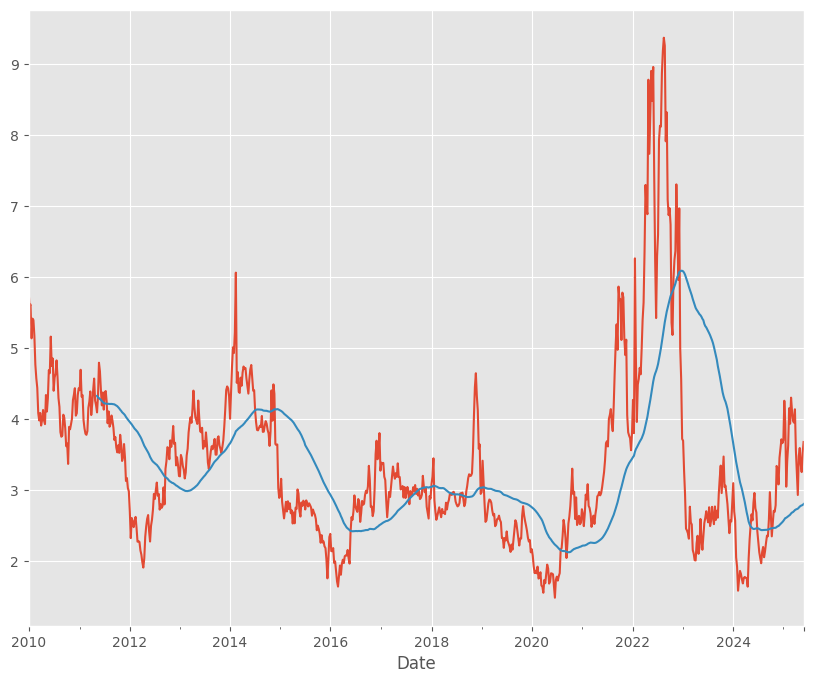

In [250]:
# view stock price evolution
plt.style.use('ggplot')

df_cla.Close.plot(figsize= (10,8))
# add rolling mean to plot
df_cla.Close.rolling(72).mean().plot(figsize= (10,8))
plt.show()

Natural gas futures exhibit a series of upward and downward swings. Occasionally, the price trends upward, followed by periods of downward movement, with some episodes showing unusually strong upward surges.

Additionally, some elements of cyclicality can be observed: downward trends tend to occur at the beginning of the years 2012, 2016, 2020, and 2024, suggesting a rough four-year cycle.

In [251]:
import plotly.express as px
import plotly.graph_objects as go

# Plot. last 1000 observations
df = df_cla#.iloc[-1000:]
fig = go.Figure(data = [go.Candlestick(x = df.index,
                open = df['Open'],
                high = df['High'],
                low = df['Low'],
                close = df['Close'])])
fig.show()

The graph is the same as the previous one. The red-highlighted areas represent periods where the closing price was lower than the opening price, indicating negative weekly returns.

## **Data Processing and Feature Extraction**

> At this stage we extract features that would be used to predict next week return's movement/direction.

We obtain rolling returns, volatility and mean reverting indicators. Just afew of them, the goal here is mainly illustration.

When it comes to features we can generate features from fundamental e.g.,  developments, earnings (for stocks), valuation metrics, technical e.g., moving averages, Relative Strenght Index and quantitative/statistical e.g., other models output(sentiments scores, predicted probability),  z-scores  and feed into the model for a more accurate prediction.

We focus on a few selected technical features herein.

In [252]:
## Compute returns and extract features

# Percentage returns
# we use log returns to approximate percentage returns
df_cla['percent_ret'] = np.log(df_cla['Close'] / df_cla['Close'].shift(1))

# simple moving average indicators
df_cla['SMA_4'] = df_cla['percent_ret'].rolling(24).mean().shift(1)
df_cla['SMA_72'] = df_cla['percent_ret'].rolling(72).mean().shift(1)

# Volatility indicator
df_cla['Vol_24'] =  df_cla['percent_ret'].rolling(24).std().shift(1)

# Mean Reverting Indicator: distance
df_cla['dist_24'] = (df_cla['Close'] - df_cla['Close'].rolling(24).mean()).shift(1)
df_cla['dist_72'] = (df_cla['Close'] - df_cla['Close'].rolling(72).mean()).shift(1)

# create 4 lag of returns: t-1, t-2, t-3, t-4
for i in range(1, 5):
  df_cla[f'lagret_{i}'] = df_cla['percent_ret'].shift(i)

# create target: t+1 (tomorrows return)
# Shift returns one day behind to serve as targets/dependent variable
df_cla['change_tomorrow'] = df_cla['percent_ret'].shift(-1)

# Drop NA values and view first 6 observation.
df_cla.dropna(inplace = True)
df_cla.head(6)

,Close,High,Low,Open,Volume,percent_ret,SMA_4,SMA_72,Vol_24,dist_24,dist_72,lagret_1,lagret_2,lagret_3,lagret_4,change_tomorrow
Date,,,,,,,,,,,,,,,,
2011-05-27,4.794,4.859,4.365,4.374,634376,0.102722,-0.001037,-0.004087,0.051245,0.124709,0.019931,0.055121,-0.024132,-0.015849,-0.070228,-0.025350
2011-06-03,4.674,4.983,4.510,4.785,764299,-0.025350,0.007048,-0.002129,0.051688,0.561625,0.498958,0.102722,0.055121,-0.024132,-0.015849,-0.057687
2011-06-10,4.412,4.811,4.408,4.661,624646,-0.057687,0.005633,-0.002548,0.052107,0.417000,0.392028,-0.025350,0.102722,0.055121,-0.024132,-0.050912
2011-06-17,4.193,4.449,4.154,4.440,581160,-0.050912,0.000705,-0.002116,0.052277,0.151917,0.140111,-0.057687,-0.025350,0.102722,0.055121,0.042262
2011-06-24,4.374,4.422,4.171,4.212,466954,0.042262,-0.002329,-0.003555,0.053100,-0.057042,-0.061903,-0.050912,-0.057687,-0.025350,0.102722,-0.056674
2011-07-01,4.133,4.411,4.064,4.372,456182,-0.056674,-0.000313,-0.002916,0.053862,0.125333,0.133292,0.042262,-0.050912,-0.057687,-0.025350,0.057588


## **Algorithmic Trading Strategies**

Algorithmic trading at its core entails programming a computer to buy or sell financial securities such as stocks, commodities, futures, options. These decisions are based on pre-defiined criteria such as value, time, volume, or other mathematical/quantitative/statistical/machine learning  models.

The algorithmic strategies define belwo are mainly _alpha seeking_ since their main objectives is ti generate postive, above-market returns independent of the market direction.

1. **Simple Moving Averages:** Simple moving average (SMA) strategies basically relies on the simple moving averages of the underlying asset process to extract trading signals for alpha generation. These stratgies have been popularized by technical analyst or chartist. The idea is that: the value of a **shorter SMA** been higher than a **longer SMA** signals a **long market position**, the reverse framework signals a neutral or **short market** position

2. **Momentum:** With momentum financial assets are assume to perform in accordance with its recent performance for some additional time. For instance, when an asset has experience positive returns on average for the last five periods (hours, days etc) it is assumed that its performance will be positive tomorrow as well.

3. **Mean Reversion:** With mean reversion strategies a financial instrument is assumed to revert to some mean or trend level, if it is currently far enough away from such a level.

4. **Machine Learning and Deep Learning (DL):** With ML and DL algorithm one generally takes a more black box approach to predicting market movement. These algorithms can learn complex, non-linear relationships between input features  and assset price movements.


More on ML and DL: Common input features include technical indicators such as SMA, mean reverting indicators, volatility indicators etc, which captures price trends and reversion dynamics.

Additionally, sentiment analysis, is also incorporated by processing news articles, earning calls, geopolitical events, social media using NLP (Natural Language Processing) to gauge market sentiments. Positive or negative sentiment scores can serve as predictive inputs, especially in short term trading.

While ML models like Random Forest and eXtreme Gradient Boost can offer high flexibility and performance, DL models (e.g. LSTM, CNN) can capture more complex temporal or spatial relationships between asset price movements and features (technical indicators, sentiment data etc).

In [253]:
# Descriptive statistics
df_cla.describe().round(4)

,Close,High,Low,Open,Volume,percent_ret,SMA_4,SMA_72,Vol_24,dist_24,dist_72,lagret_1,lagret_2,lagret_3,lagret_4,change_tomorrow
count,731.0000,731.0000,731.0000,731.0000,7.310000e+02,731.0000,731.0000,731.0000,731.0000,731.0000,731.0000,731.0000,731.0000,731.0000,731.0000,731.0000
mean,3.2802,3.4786,3.1023,3.2819,6.888871e+05,-0.0003,-0.0002,-0.0006,0.0696,-0.0088,-0.0506,-0.0003,-0.0003,-0.0002,-0.0004,-0.0004
std,1.2708,1.3914,1.1498,1.2660,2.156491e+05,0.0752,0.0143,0.0072,0.0269,0.7545,1.1959,0.0752,0.0752,0.0751,0.0752,0.0751
min,1.4820,1.7120,1.4320,1.4410,2.465000e+05,-0.3324,-0.0565,-0.0204,0.0239,-3.5567,-3.5998,-0.3324,-0.3324,-0.3324,-0.3324,-0.3324
25%,2.5555,2.6930,2.4330,2.5635,5.300270e+05,-0.0417,-0.0077,-0.0052,0.0490,-0.3255,-0.6674,-0.0417,-0.0417,-0.0416,-0.0417,-0.0417
50%,2.9400,3.0600,2.8050,2.9390,6.566670e+05,-0.0010,0.0001,-0.0005,0.0660,-0.0155,-0.0210,-0.0010,-0.0010,-0.0010,-0.0015,-0.0010
75%,3.7040,3.8995,3.5730,3.7135,8.193410e+05,0.0447,0.0087,0.0038,0.0817,0.3073,0.5153,0.0447,0.0447,0.0447,0.0447,0.0444
max,9.3750,10.0280,8.8700,9.3720,1.699135e+06,0.4995,0.0365,0.0182,0.1628,3.7092,4.6633,0.4995,0.4995,0.4995,0.4995,0.4995





**Regarding returns**:

The maximum weekly jump recorded was +49.95%,
The maximum weekly plunge was −33.24%,
The 75th and 25th percentiles (quartiles) are 4.7% and −4.17%, respectively.
The median return is - 0.1%, and the mean is -0.03%.
This suggests that the distribution of returns is slightly positively skewed.

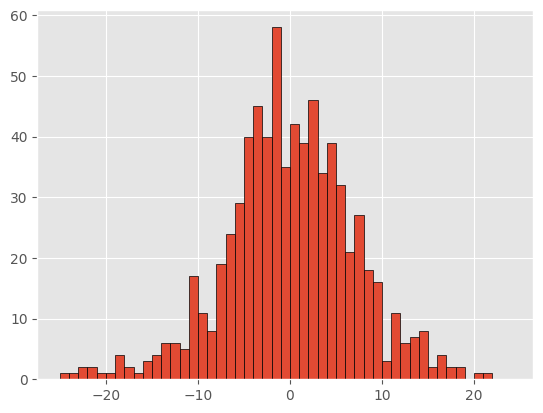

In [254]:
# View histogram
#np.log(1 + df_cla['percent_ret']).hist(bins=range(-15,15), edgecolor='black');

(df_cla['percent_ret'] * 100).hist(bins=range(-25,25), edgecolor='black');
plt.show()

> The histogram does not support the aforementioned arguement on skewness. It depicts more extreme returns on the left, thus negatively skewed.

In [255]:
#print(f'Mean : {df_cla.percent_ret.mean():.4f}\n')
#print(f'StandDev: {df_cla.percent_ret.std():.4f}\n')

In [256]:
# Obtain labels
df_cla['change_tomorrow'] = np.where( df_cla['change_tomorrow'] < 0, 0, 1)
df_cla
df_cla.head(6)

,Close,High,Low,Open,Volume,percent_ret,SMA_4,SMA_72,Vol_24,dist_24,dist_72,lagret_1,lagret_2,lagret_3,lagret_4,change_tomorrow
Date,,,,,,,,,,,,,,,,
2011-05-27,4.794,4.859,4.365,4.374,634376,0.102722,-0.001037,-0.004087,0.051245,0.124709,0.019931,0.055121,-0.024132,-0.015849,-0.070228,0
2011-06-03,4.674,4.983,4.510,4.785,764299,-0.025350,0.007048,-0.002129,0.051688,0.561625,0.498958,0.102722,0.055121,-0.024132,-0.015849,0
2011-06-10,4.412,4.811,4.408,4.661,624646,-0.057687,0.005633,-0.002548,0.052107,0.417000,0.392028,-0.025350,0.102722,0.055121,-0.024132,0
2011-06-17,4.193,4.449,4.154,4.440,581160,-0.050912,0.000705,-0.002116,0.052277,0.151917,0.140111,-0.057687,-0.025350,0.102722,0.055121,1
2011-06-24,4.374,4.422,4.171,4.212,466954,0.042262,-0.002329,-0.003555,0.053100,-0.057042,-0.061903,-0.050912,-0.057687,-0.025350,0.102722,0
2011-07-01,4.133,4.411,4.064,4.372,456182,-0.056674,-0.000313,-0.002916,0.053862,0.125333,0.133292,0.042262,-0.050912,-0.057687,-0.025350,1


In [257]:
print(f' Value Counts : {df_cla.change_tomorrow.value_counts()}')

# Split data, use last 52 weeks data for testing
df_cla_is = df_cla.iloc[:-52]
df_cla_oos = df_cla.iloc[-52:]

 Value Counts : change_tomorrow
0    368
1    363
Name: count, dtype: int64


# **Model Development**

In this section we try to answer the question, how does the tree algortihm works.

**How exactly does the tree algorithm actually works ?**

The decision tree is a data structure consisting of **Hierarchical Nodes**. The tree like structure is like this (from top to bottom): First the **Root**, then the **internal Nodes** and lastly the **Leafs**.

The root starts with a single feature (input), splitted into two branches, which results to the **first internal nodes**. Thereafter, at that **depth level** using a single feature, the first internal nodes (each of the two) is then splitted into two at the next depth level,  to result to the **next internal nodes** (morethan 2 at this point) and so on until the **leafs** are gotten, which presents the prediction.

- Therefore the **maximum depth** (number of depth levels) equals: the root(1) plus the total levels of internal nodes (**LIN**), thus **maximum depth**  = **1 + LIN**.

The nodes of a classification tree are grown recursively; in other words, the obtention of an internal node or a leaf depends on the state of its predecessors.

Moreover, in order to produce the **purest leaves possible**, at each internal node, a tree asks a question involving a selected feature **f** and a split-point **sp** - aiming to divide the data in a way that maximizes class separation.

- **How then does it know which feature and which split-point to pick?**

$$\,$$
(another good question Gildas... )

It does so by maximizing **Information gain! IG** The tree considers that every internal node contains information and aims at maximizing the Information Gain obtained after each split (Gildas answering... ). Consider the case where an (internal) node with N samples is split into a left-node with N-left samples and a right-node with N-right samples.


The information gain **IG** for such split is given by the formula shown here:

$$IG(f, sp) = I(parent) -  \frac{N_{left}}{N} * I(left) - \frac{N_{right}}{N} * I(right)$$

Where:

-  $I(node)$ represents the **impurity of the node**.
- $N$, $\,$ $N_{left}$, $\,$  $N_{right}$,  $\,$  : total number of samples, $\,$  left samples, $\,$  right samples.



$$\,$$
$$\,$$
Another interesting question that may arise in mind here is:
- **What criterion is used to measure the impurity of a node?**
$$\,$$


Well, there exist different criteria one can use, for instance the **gini-index, entropy, log loss** for classification models.  See more [see more](https://scikit-learn.org/1.5/modules/tree.html#tree-mathematical-formulation). **squared error, friedman_mse, poisson** for regression task.


As ealier highlighted at each Node, data is splitted based on **f** and **sp** to **maximize the** $IG(node)$.

If $IG(node) = 0$, declare the node a **leaf**. Thus spliting for that particular node ceases. It can also stop based aspects such as maximum depth set, or some other parameter constraint.

Now some ML modelling...

In [258]:
# normalize
norm = False
# Obtain target and features
target = df_cla_is.change_tomorrow
explanatory = df_cla_is.drop(columns= ['Close', 'High', 'Low', 'Open', 'Volume', 'percent_ret', 'change_tomorrow'])

# mean and std
mu, std = explanatory.mean(), explanatory.std()

# normalize
if norm:
  explanatory = (explanatory - mu) / std

target_oos = df_cla_oos.change_tomorrow
explanatory_oos = df_cla_oos.drop(columns= ['Close', 'High', 'Low', 'Open', 'Volume', 'percent_ret', 'change_tomorrow'])

# normalize
if norm:
  explanatory_oos = (explanatory_oos - mu) / std

In [259]:
# print explanatory columns
print('Explanatory columns: ', explanatory.columns)

Explanatory columns:  Index(['SMA_4', 'SMA_72', 'Vol_24', 'dist_24', 'dist_72', 'lagret_1',
       'lagret_2', 'lagret_3', 'lagret_4'],
      dtype='object')


In [260]:
from sklearn.tree import DecisionTreeClassifier

# Instantiate and fit tree model, with max depth 10
model_dt = DecisionTreeClassifier(max_depth= 10, criterion= "gini", random_state= 75)
model_dt.fit(explanatory, target)

DecisionTreeClassifier(max_depth=10, random_state=75)

In [261]:
# View parameters: DT
np.array(model_dt.get_params())

array({'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': 10, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': 75, 'splitter': 'best'},
      dtype=object)

In [262]:
from sklearn.ensemble import RandomForestClassifier

# Instantiate an fit forest model, with max depth 10
model_rf = RandomForestClassifier(max_depth=10, n_estimators= 100, n_jobs = -1,
 oob_score =  True,  criterion= "gini", random_state=75)
model_rf.fit(explanatory, target)

RandomForestClassifier(max_depth=10, n_jobs=-1, oob_score=True, random_state=75)

In [263]:
# print oob score
print(f'OOB score: {model_rf.oob_score_:.2f}\n')
# View parameters: RF
np.array(model_rf.get_params())

OOB score: 0.49



array({'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': 10, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 100, 'n_jobs': -1, 'oob_score': True, 'random_state': 75, 'verbose': 0, 'warm_start': False},
      dtype=object)

> We will start with a smaller number for the max depth of the base learner to avoid overfitting.

In [264]:
from xgboost import XGBClassifier
# Instantiate an fit xgb model, with max depth 3
model_gb = XGBClassifier(max_depth= 3, n_estimators= 100, random_state=75)
model_gb.fit(explanatory, target)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, random_state=75, ...)

In [265]:
# view params: xgb
np.array(model_gb.get_params())

array({'objective': 'binary:logistic', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': None, 'device': None, 'early_stopping_rounds': None, 'enable_categorical': False, 'eval_metric': None, 'feature_types': None, 'gamma': None, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': None, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': 3, 'max_leaves': None, 'min_child_weight': None, 'missing': nan, 'monotone_constraints': None, 'multi_strategy': None, 'n_estimators': 100, 'n_jobs': None, 'num_parallel_tree': None, 'random_state': 75, 'reg_alpha': None, 'reg_lambda': None, 'sampling_method': None, 'scale_pos_weight': None, 'subsample': None, 'tree_method': None, 'validate_parameters': None, 'verbosity': None},
      dtype=object)

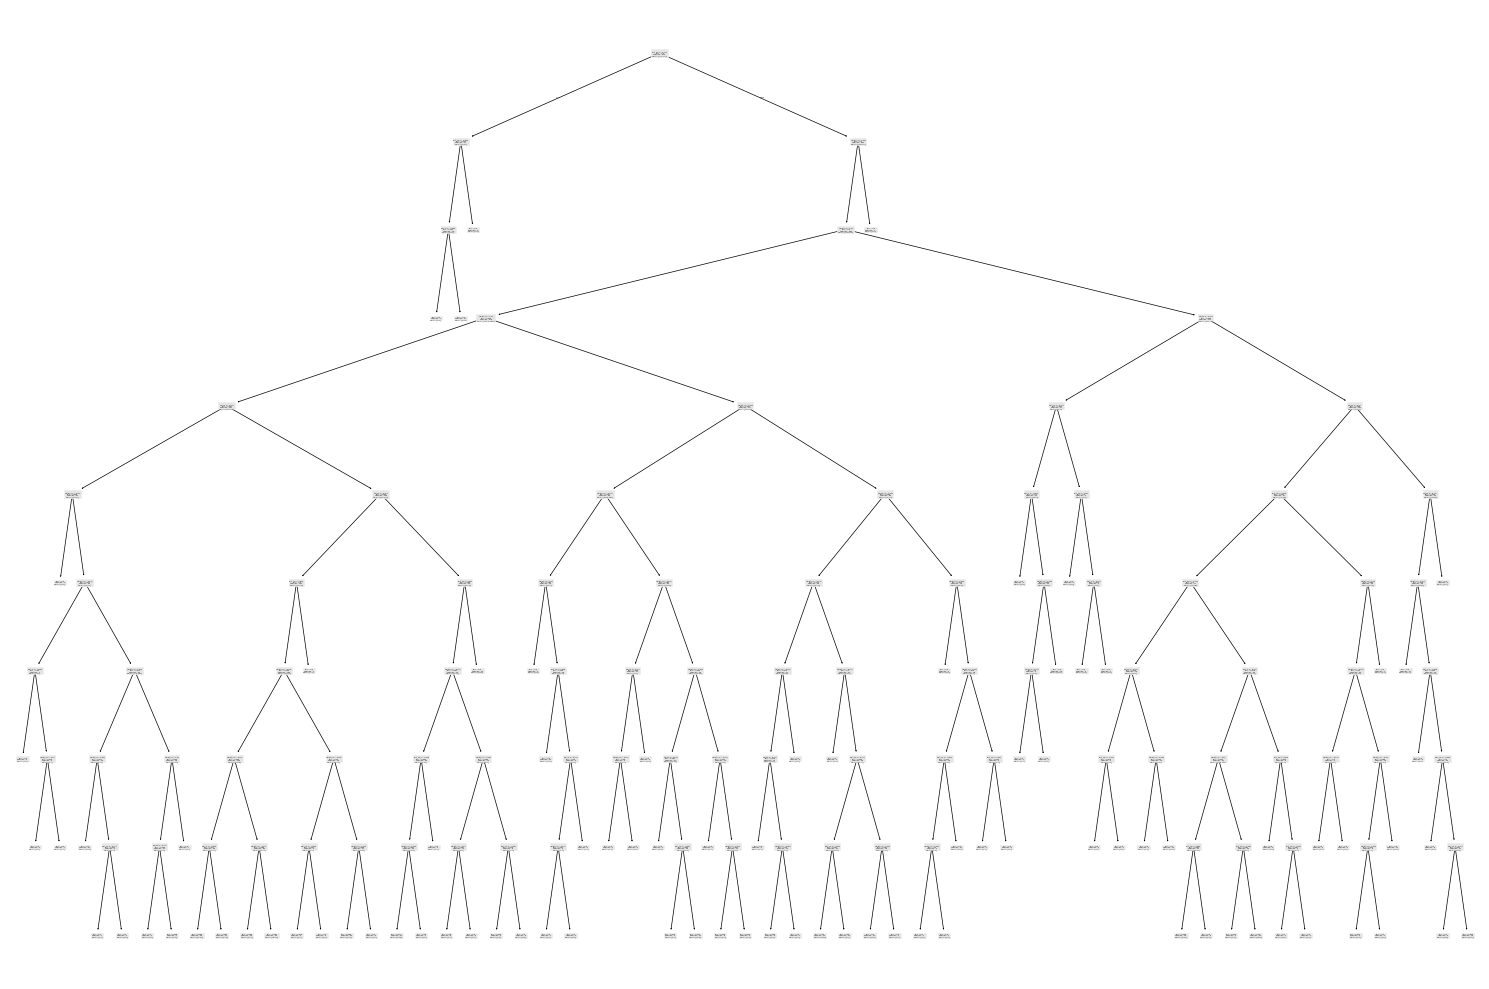

In [266]:
# @title View Tree
from sklearn.tree import plot_tree

plt.figure(figsize=(15,10))
plot_tree(decision_tree= model_dt, feature_names= model_dt.feature_names_in_)
# adjust fig size to fit well
plt.tight_layout()
plt.show()

> Although we can not actually see the details at each split, we can at least notice there are indeed 10 depth levels present on the tree.

lagret_3    0.183289
Vol_24      0.153579
lagret_4    0.137378
dist_72     0.100784
SMA_72      0.097813
dtype: float64 



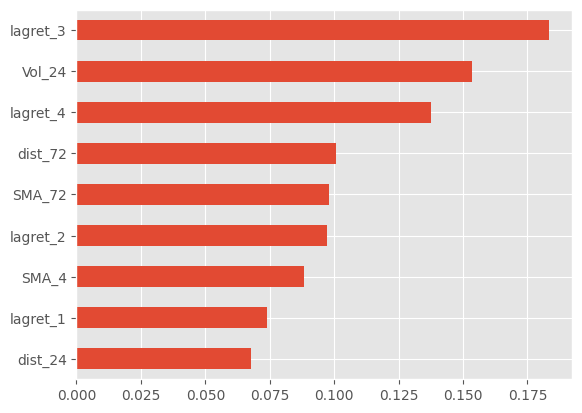

In [267]:
# feature impotance: Decision tree
importances = model_dt.feature_importances_
import_dt = pd.Series(importances, index= model_dt.feature_names_in_  )
print(import_dt.nlargest(5), '\n')
import_dt.nsmallest(len(import_dt)).plot(kind= 'barh')
plt.show()

lagret_4    0.125792
lagret_2    0.122130
lagret_3    0.119335
Vol_24      0.119149
SMA_4       0.106501
dtype: float64 



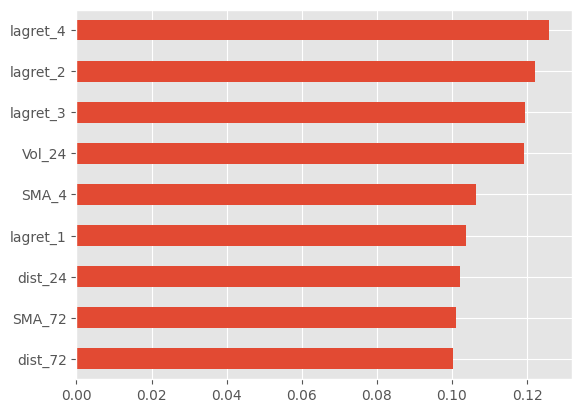

In [268]:
# feature importance: Random Forest
importances = model_rf.feature_importances_
import_rf = pd.Series(importances, index= model_rf.feature_names_in_)
print(import_rf.nlargest(5), '\n')
import_rf.nsmallest(len(import_rf)).plot(kind= 'barh')
plt.show()

lagret_4    0.123403
Vol_24      0.122181
SMA_4       0.118065
lagret_1    0.113013
lagret_3    0.108217
dtype: float32 



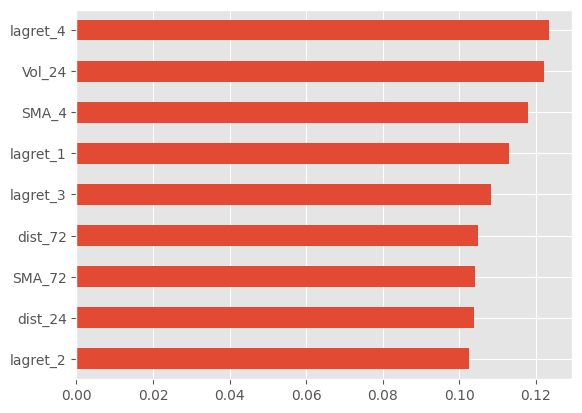

In [269]:
# feature importance: xgb model
importances = model_gb.feature_importances_
import_gb = pd.Series(importances, index= model_gb.feature_names_in_)
print(import_gb.nlargest(5), '\n')
import_gb.nsmallest(len(import_gb)).plot(kind= 'barh')
plt.show()

**In-Sample**

In [270]:
# import accuracy mettric
from sklearn.metrics import accuracy_score
# Concat predicted values and actual values in a frame
## DT
y_pred_dt = model_dt.predict(X = explanatory)
df_pred_dt = pd.DataFrame(target)
df_pred_dt['prediction'] = y_pred_dt
print(df_pred_dt.sum())
# compute accuracy
print(f'Accuracy: {accuracy_score(df_pred_dt.change_tomorrow, df_pred_dt.prediction):.2f}')
df_pred_dt.head(6)

change_tomorrow    337
prediction         306
dtype: int64
Accuracy: 0.86


,change_tomorrow,prediction
Date,,
2011-05-27,0,0
2011-06-03,0,0
2011-06-10,0,0
2011-06-17,1,1
2011-06-24,0,0
2011-07-01,1,1


In [271]:
# RF
y_pred_rf = model_rf.predict(X = explanatory)
df_pred_rf = pd.DataFrame(target)
df_pred_rf['prediction'] = y_pred_rf
print(df_pred_rf.sum())
print(f'Accuracy: {accuracy_score(df_pred_rf.change_tomorrow, df_pred_rf.prediction):.2f}')
df_pred_rf.head(6)

change_tomorrow    337
prediction         336
dtype: int64
Accuracy: 1.00


,change_tomorrow,prediction
Date,,
2011-05-27,0,0
2011-06-03,0,0
2011-06-10,0,0
2011-06-17,1,1
2011-06-24,0,0
2011-07-01,1,1


In [272]:
# xgb
y_pred_gb = model_gb.predict(X = explanatory)
df_pred_gb = pd.DataFrame(target)
df_pred_gb['prediction'] = y_pred_gb
print(df_pred_gb.sum())
print(f'Accuracy: {accuracy_score(df_pred_gb.change_tomorrow, df_pred_gb.prediction):.2f}')
df_pred_gb

change_tomorrow    337
prediction         334
dtype: int64
Accuracy: 0.97


,change_tomorrow,prediction
Date,,
2011-05-27,0,0
2011-06-03,0,0
2011-06-10,0,0
2011-06-17,1,1
2011-06-24,0,0
...,...,...
2024-04-26,1,1
2024-05-03,1,1
2024-05-10,1,1


## **Evaluate the model**

Model evaluation will be carried out using the **accuracy metric**, a number betweeb 0 and 1. or 0% to 100%, the higher the better.

Typically accuracy of above 85% on the test set is ideal!

In [273]:
# DT
compdt = df_pred_dt.change_tomorrow == df_pred_dt.prediction
print('DT sum', compdt.sum(), '\n')

# RF
comprf = df_pred_rf.change_tomorrow == df_pred_rf.prediction
print('RF sum', comprf.sum(), '\n')

# xgb
compgb = df_pred_gb.change_tomorrow == df_pred_gb.prediction
print('xgb sum', compgb.sum(), '\n')
# Length of df
print('Length of data: ', len(comprf))

DT sum 582 

RF sum 676 

xgb sum 658 

Length of data:  679


In [274]:
# Accuracy

## DT
print('DT accuracy: ', compdt.sum() / len(compdt), '\n')
## RF
print('RF accuracy: ', comprf.sum() / len(comprf), '\n')
## xgb
print('xgb accuracy: ', compgb.sum() / len(compgb))

DT accuracy:  0.8571428571428571 

RF accuracy:  0.9955817378497791 

xgb accuracy:  0.9690721649484536


**Out-sample**

In [275]:
# Concat predicted values and actual values in a frame: Out-Sample

## DT
y_pred_dt = model_dt.predict(X = explanatory_oos)
df_pred_dt = pd.DataFrame(target_oos)
df_pred_dt['prediction'] = y_pred_dt
print(df_pred_dt.sum())
df_pred_dt

# concat head and tails
pd.concat([df_pred_dt.head(3), df_pred_dt.tail(2)])

change_tomorrow    26
prediction         24
dtype: int64


,change_tomorrow,prediction
Date,,
2024-05-31,1,0
2024-06-07,0,0
2024-06-14,0,0
2025-05-16,1,0
2025-05-23,1,0


In [276]:
# Concat predicted values and actual values in a frame

## RF
y_pred_rf = model_rf.predict(X = explanatory_oos)
df_pred_rf = pd.DataFrame(target_oos)
df_pred_rf['prediction'] = y_pred_rf
# prob
df_pred_rf['prob'] = model_rf.predict_proba(explanatory_oos)[:,1]
print(df_pred_rf.sum())
df_pred_rf

# concat head and tails
pd.concat([df_pred_rf.head(15), df_pred_rf.tail(2)])

change_tomorrow    26.00000
prediction         26.00000
prob               26.95456
dtype: float64


,change_tomorrow,prediction,prob
Date,,,
2024-05-31,1,1,0.563929
2024-06-07,0,0,0.461253
2024-06-14,0,0,0.476777
2024-06-21,0,0,0.447788
2024-06-28,0,1,0.506042
2024-07-05,0,0,0.453869
2024-07-12,0,1,0.613762
2024-07-19,0,1,0.696805
2024-07-26,1,1,0.729263


In [277]:
## xgb
y_pred_gb = model_gb.predict(X = explanatory_oos)
df_pred_gb = pd.DataFrame(target_oos)
df_pred_gb['prediction'] = y_pred_gb
print(df_pred_gb.sum())
df_pred_gb

# concat
pd.concat([df_pred_gb.head(3), df_pred_gb.tail(2)])

change_tomorrow    26
prediction         34
dtype: int64


,change_tomorrow,prediction
Date,,
2024-05-31,1,1
2024-06-07,0,0
2024-06-14,0,0
2025-05-16,1,1
2025-05-23,1,1


In [278]:
# Evaluate models

# DT
compdt = df_pred_dt.change_tomorrow == df_pred_dt.prediction
print('DT sum', compdt.sum(), '\n')

# RF
comprf = df_pred_rf.change_tomorrow == df_pred_rf.prediction
print('RF sum', comprf.sum(), '\n')

# xgb
compgb = df_pred_gb.change_tomorrow == df_pred_gb.prediction
print('xgb sum', compgb.sum(), '\n')
# Length of df
print('Length of data: ', len(comprf))

DT sum 24 

RF sum 28 

xgb sum 32 

Length of data:  52


In [279]:
# Accuracy

## DT
print('DT accuracy  : ', round(compdt.sum() / len(compdt), 4), '\n')
## RF
print('RF accuracy  : ', round(comprf.sum() / len(comprf), 4), '\n')
## xgb
print('xgb accuracy : ', round(compgb.sum() / len(compgb), 4) )

DT accuracy  :  0.4615 

RF accuracy  :  0.5385 

xgb accuracy :  0.6154


Test accuracies are poor and much lower than the trainning accuracies. This implies we have achieved a low training set error and a high test set error - a text book definition of overfitting.

**Overfitting**: When a model overfits the training set, its predictive power on **unseen datasets** is pretty low. The model is said to have clearly memorized the **noise** present in the **training set**.
$$\,$$



# **Bactesting**

Backtesting is the process of evaluating a trading or investment strategy by applying it to historical data to see how it would have performed in the past.

The goal is validate a strategies logic before deploying real capital.


We use the Python package vectorbt. Which is short for vectorized bactesting, another name for array programming. It is reported to be computationally efficient compared to loop.

**Strategy logic:** If our model predicts next day movement to be: 1 - we buy! 0 - we sell!


> Lastly, we display backtest results for the strategy with best test accuracy, which is xgb.


In [280]:
#!pip install vectorbt

In [281]:
# import package for backtest
import vectorbt as vbt

# View version
vbt.__version__

'0.27.3'

In [282]:
# Bactest: xgb
bactest_gb = vbt.Portfolio.from_signals(close = df_cla_oos['Close'], entries= df_pred_gb['prediction'] == 1, \
                                        exits= df_pred_gb['prediction'] ==0, freq= '1W' )
stats_gb = bactest_gb.stats()
name = 'GB: ' + tickers[2]
# print
print(name)
stats_gb.to_frame(name= name)

GB: NG=F


,GB: NG=F
Start,2024-05-31 00:00:00
End,2025-05-23 00:00:00
Period,364 days 00:00:00
Start Value,100.0
End Value,209.409225
Total Return [%],109.409225
Benchmark Return [%],24.849342
Max Gross Exposure [%],100.0
Total Fees Paid,0.0
Max Drawdown [%],22.073678




**Summary**

Above are the reported statistics for the **ML trading strategy – xgb**, implemented on the **energy commodity – natural gas futures**. The model was trained using weekly data from January 2010 to the week before May 31, 2025, and tested using weekly data from May 31, 2024, to May 23, 2025.

The values are mostly self-explanatory, but we’ll highlight a few. The strategy initiated a total of 11 trades, with a win rate of 70%. The average winning trade yielded 16.99%, which is higher than the average losing trade of -9.66% – this is a fairly good result. However, the duration of losing trades (28 days) was longer than that of winning trades (18 days), which is not a positive sign.

Using volatility as a risk metric, a Sharpe ratio of 1.77 implies that the expected return is 1.77 units per unit of risk. This suggests the strategy is quite profitableat at the given risk level. The total return supports this, with a reported gain of 109%, meaning an initial investment would have grown to (100 + 109) 209%.

In [283]:
# Below we have the order df depicting size of trades
orders_gb = bactest_gb.orders.records_readable
pd.concat([orders_gb.head(3), orders_gb.tail(2)])

,Order Id,Column,Timestamp,Size,Price,Fees,Side
0,0,0,2024-05-31,35.448421,2.821,0.0,Buy
1,1,0,2024-06-07,35.448421,2.959,0.0,Sell
2,2,0,2024-06-28,43.379604,2.418,0.0,Buy
19,19,0,2025-04-25,61.388686,3.479,0.0,Sell
20,20,0,2025-05-02,59.457473,3.592,0.0,Buy


In [284]:
# plot bactest: xgb
bactest_gb.plot().show()
plt.show()

**Summary**


Above we see a visualization of the strategy's trajectory, indicating periods of buy and sell; we further see the size of the closed and opened trade, as well as the diagram depicting we currently have an open trade; lastly the cumulative gains of the strat is showned, and notice the strategy is showned to be way better than the benchmark strategy of buy and hold.
$\,$

$\quad$

**Next Step**

Now we want automate the process so we can apply to different sets of energy commodities/securities.

The function below basically implements the above concepts we presented, with few additions.  



In [285]:
#@title Feature Processing and Extraction Function

def Prepro_FeatureExtraction(ticker: str, start_date: str= "2010-01-01", test_size: int= 52, normalize: bool= False):
  """
   Function to download assets historical closing prices, compute features, obtain binary target...
   to be used to train models and backtest ML trading strategy.

   Args:
      ticker    : the symbol of the energy commodity/stock price to be downloaded
      start_date: the start date of the historical data to be downloaded
      test_size : the length of last n observations to be used to test strategy
      normalize : if true then normalize features to be used to train model

  Prints: ticker, value counts of target, features column names


   Returns:
          explanatory df: explanotary variables/features
          target df     : target variable
          For in-sample and out-sample data sets
  """

  ## Download history
  DF = yf.download(ticker, start= start_date, auto_adjust= True,  interval= '1wk', multi_level_index= False)
  df = pd.DataFrame(DF.Close)

  # assert no missing values
  assert df.isna().sum().sum() == 0

  ## Preprocesing and feature extraction
  # We use log returns as approximation of percentage returns
  df['percent_ret'] = np.log(df['Close'] / df['Close'].shift(1))

  # Compute rolling average returns
  df['SMA_24'] = df['percent_ret'].rolling(24).mean().shift(1)
  df['SMA_72'] = df['percent_ret'].shift(1).rolling(72).mean().shift(1)

  # Volatility Indicator
  df['Vol_24'] = df['percent_ret'].rolling(24).std().shift(1)

  # Mean Reverting Indicator: distance
  df['dist_24'] = (df['Close'] - df['Close'].rolling(24).mean()).shift(1)
  df['dist_72'] = (df['Close'] - df['Close'].rolling(72).mean()).shift(1)

  # create 4 lag returns: t-1, t-2, t-3, t-4
  for i in range(1, 5):
    df[f'lagret_{i}'] = df['percent_ret'].shift(i)
  # Drop na values
  df.dropna(inplace = True)

  # create target: t+1 (tomorrow)
  # Shift returns one day behind to serve as target/dependent variable
  df['change_tomorrow'] = df['percent_ret'].shift(-1)
  # classify returns to  1 and 0
  df['change_tomorrow'] = np.where( df['change_tomorrow'] > 0, 1, 0)

  print(f'\nStock.Commodity.Futures Symbol: {ticker}')
  print(f' Value Counts : {df.change_tomorrow.value_counts()}', '\n')

  # Split data: In-sample - is, and Out-of-Sample - os
  df_is = df.iloc[:-test_size]
  df_oos = df.iloc[-test_size:]

  # Obtain target and features: In sample
  target_is = df_is.change_tomorrow
  explanatory_is = df_is.drop(columns= ['Close', 'percent_ret', 'change_tomorrow'])

  # compute mean and std
  mu, std = explanatory_is.mean(), explanatory_is.std()

  # normalize
  if normalize:
    explanatory_is = (explanatory_is - mu) / std

  # print explanatory columns
  print('Explanatory columns: ', explanatory_is.columns)

  # Obtain target and features: Out sample
  target_oos = df_oos.change_tomorrow
  explanatory_oos = df_oos.drop(columns= ['Close', 'percent_ret', 'change_tomorrow'])

  # normalize
  if normalize:
    explanatory_oos = (explanatory_oos - mu) / std

  return explanatory_is, target_is, explanatory_oos, target_oos, df_is, df_oos


In [306]:
#@title ML Model Function

def ML_model(model_name: str= "RF", explanatory_is: pd.DataFrame= None, target_is: pd.Series= None):
  """
  Function to instantiate and fit ML models.

  Args :
       model_name    : what model to be trained, either Decision tree - DT, Random
       Forest - RF, or eXtreme Gradient Boosting - XGB.
       explanatory_is: explanotary variables
       target_is.    : target variable

  Prints: Prints name of fitted model

  Returns: trained ML model, ready to be used for prediction
  """

  ## Inantiate and fit choosen (DT, RF or XGB) model
  if model_name == 'DT':
    model = DecisionTreeClassifier(max_depth=10, criterion= "gini", random_state= 75)
    model.fit(explanatory_is, target_is)
    print(f'\n--------*{model_name}*----------\n')
    print('Fitting DT Model')
    print(f'--------*{model_name}*----------\n')
  elif model_name == 'RF':
    model = RandomForestClassifier(max_depth=10, n_estimators= 100, criterion= "gini", random_state=75)
    model.fit(explanatory_is, target_is)
    print(f'\n--------*{model_name}*----------\n')
    print('Fitting RF Model')
    print(f'--------*{model_name}*----------\n')
  elif model_name == 'XGB':
    model = XGBClassifier(max_depth= 3, n_estimators= 100, random_state=75)
    model.fit(explanatory_is, target_is)
    print(f'\n--------*{model_name}*----------\n')
    print('Fitting XGB Model')
    print(f'--------*{model_name}*----------\n')
  else:
    print('Invalid model: ', model_name, '. Model must be either DT, RF or XGB')

  return model

In [307]:

def ML_StratBacktest(ticker, start_date= "2010-01-01", test_size= 52, normalize= False, model_name= 'RF',
                           init_cash: int= 100, fees: float= 0.002) -> pd.DataFrame:
  """
   Function to combine elements of Prepro_FeatureExtraction and ML_model functions,
   to carry out ML trading strategy bactesting.

   Args:
      ...
      init_cash: initial investment
      fees     : trading fees

   Prints:
          ... the train and test accuracy, also the accuracy on only the first five predictions.
          Also the initial investment value, the expected terminal value

   Return:
          Returns a backtest statistics dataframe
  """

  # call Prepro_FeatureExtraction function
  explanatory_is, target_is, explanatory_oos, target_oos, df_is, df_oos = Prepro_FeatureExtraction(ticker= ticker, start_date= start_date, test_size= test_size, normalize= normalize )

  # call ML model function
  model = ML_model(model_name= model_name, explanatory_is= explanatory_is, target_is= target_is)

  ## Print In-sample and Out-sample accuracy score
  # Predictions on train and test set
  pred_is = model.predict(explanatory_is)
  pred_oos = model.predict(explanatory_oos)

  res = pd.DataFrame(target_oos)
  res['prediction'] =  pred_oos

  # print first 3 and last two prediction
  print('First 3 and last two predictions')
  print(pd.concat([res.head(3), res.tail(2)]))
  print()


  # Predictions on train set
  print(f'Pred accuracy for: {ticker}')
  # Train score
  print(f'Train accuracy score: {accuracy_score(pred_is, target_is):.2f}')
  # Test score
  print(f'Test accuracy score: {accuracy_score(pred_oos, target_oos):.2f}')

  # test accuracy on first five predictions
  print(f'Test accuracy score for first five trading weeks only: {accuracy_score(pred_oos[:5], target_oos[:5])}')
  print()

  # Bactest Result
  # Initial investment
  print(f'Initial investment value: {ticker}')
  price = df_oos.Close
  print(init_cash)


  bactest_results = vbt.Portfolio.from_signals(price, init_cash= init_cash, \
                    entries = pred_oos == 1, exits= pred_oos == 0, fees = 0.002, freq= '1W')

  print(f'Expected Terminal value: {ticker}')
  print(f'{(bactest_results.total_return() * 100) + 100}\n\n\n')
  stats = bactest_results.stats()
  name = model_name + ': ' + ticker


  return  stats.to_frame(name= name)

In [308]:
# View stock symbols
print(tickers)
print()

['CL=F', 'BZ=F', 'NG=F', 'QG=F', 'AGI']



In [309]:
# List of energy-related tickers
tickers = [
    "CL=F",  # WTI Crude Oil
    "BZ=F",  # Brent Crude Oil
    "NG=F",  # Natural Gas
    "QG=F",  # E-mini Natural Gas Futures
    "AGI" ,   # Alomos Gold
]

In [310]:
# do a list comprehension across each ticker and and save results: DT
result_CLAS_dt = [ML_StratBacktest(ticker, model_name= 'DT') for ticker in tickers]

[*********************100%***********************]  1 of 1 completed


Stock.Commodity.Futures Symbol: CL=F
 Value Counts : change_tomorrow
1    373
0    359
Name: count, dtype: int64 

Explanatory columns:  Index(['SMA_24', 'SMA_72', 'Vol_24', 'dist_24', 'dist_72', 'lagret_1',
       'lagret_2', 'lagret_3', 'lagret_4'],
      dtype='object')



--------*DT*----------

Fitting DT Model
--------*DT*----------

First 3 and last two predictions
            change_tomorrow  prediction
Date                                   
2024-06-14                0           1
2024-06-21                1           1
2024-06-28                0           0
2025-05-30                1           1
2025-06-06                0           1

Pred accuracy for: CL=F
Train accuracy score: 0.76
Test accuracy score: 0.48
Test accuracy score for first five trading weeks only: 0.6

Initial investment value: CL=F
100
Expected Terminal value: CL=F
87.46755981818742





[*********************100%***********************]  1 of 1 completed



Stock.Commodity.Futures Symbol: BZ=F
 Value Counts : change_tomorrow
1    372
0    360
Name: count, dtype: int64 

Explanatory columns:  Index(['SMA_24', 'SMA_72', 'Vol_24', 'dist_24', 'dist_72', 'lagret_1',
       'lagret_2', 'lagret_3', 'lagret_4'],
      dtype='object')

--------*DT*----------

Fitting DT Model
--------*DT*----------

First 3 and last two predictions
            change_tomorrow  prediction
Date                                   
2024-06-14                1           1
2024-06-21                1           0
2024-06-28                0           1
2025-05-30                1           1
2025-06-06                0           1

Pred accuracy for: BZ=F
Train accuracy score: 0.74
Test accuracy score: 0.50
Test accuracy score for first five trading weeks only: 0.2

Initial investment value: BZ=F
100
Expected Terminal value: BZ=F
84.01780612297428





...


Stock.Commodity.Futures Symbol: NG=F
 Value Counts : change_tomorrow
0    369
1    363
Name: count, dtype: int64 

Explanatory columns:  Index(['SMA_24', 'SMA_72', 'Vol_24', 'dist_24', 'dist_72', 'lagret_1',
       'lagret_2', 'lagret_3', 'lagret_4'],
      dtype='object')

--------*DT*----------

Fitting DT Model
--------*DT*----------

First 3 and last two predictions
            change_tomorrow  prediction
Date                                   
2024-06-14                0           0
2024-06-21                0           1
2024-06-28                0           0
2025-05-30                0           0
2025-06-06                0           1

Pred accuracy for: NG=F
Train accuracy score: 0.86
Test accuracy score: 0.52
Test accuracy score for first five trading weeks only: 0.6

Initial investment value: NG=F
100
Expected Terminal value: NG=F
124.63489813891732





[*********************100%***********************]  1 of 1 completed



Stock.Commodity.Futures Symbol: QG=F
 Value Counts : change_tomorrow
0    370
1    362
Name: count, dtype: int64 

Explanatory columns:  Index(['SMA_24', 'SMA_72', 'Vol_24', 'dist_24', 'dist_72', 'lagret_1',
       'lagret_2', 'lagret_3', 'lagret_4'],
      dtype='object')

--------*DT*----------

Fitting DT Model
--------*DT*----------

First 3 and last two predictions
            change_tomorrow  prediction
Date                                   
2024-06-14                0           0
2024-06-21                0           1
2024-06-28                0           0
2025-05-30                0           1
2025-06-06                0           1

Pred accuracy for: QG=F
Train accuracy score: 0.91
Test accuracy score: 0.46
Test accuracy score for first five trading weeks only: 0.4

Initial investment value: QG=F
100
Expected Terminal value: QG=F
132.18022507247684





[*********************100%***********************]  1 of 1 completed


Stock.Commodity.Futures Symbol: AGI
 Value Counts : change_tomorrow
1    369
0    363
Name: count, dtype: int64 

Explanatory columns:  Index(['SMA_24', 'SMA_72', 'Vol_24', 'dist_24', 'dist_72', 'lagret_1',
       'lagret_2', 'lagret_3', 'lagret_4'],
      dtype='object')

--------*DT*----------

Fitting DT Model
--------*DT*----------

First 3 and last two predictions
            change_tomorrow  prediction
Date                                   
2024-06-14                0           1
2024-06-21                1           1
2024-06-28                1           1
2025-05-30                1           0
2025-06-06                0           0

Pred accuracy for: AGI
Train accuracy score: 0.86
Test accuracy score: 0.38
Test accuracy score for first five trading weeks only: 0.6

Initial investment value: AGI
100
Expected Terminal value: AGI
119.51852876098643





In [320]:
#  list comprehension and and save results: RF
result_CLAS_rf = [ML_StratBacktest(ticker, model_name= 'RF', normalize= True) for ticker in tickers]

[*********************100%***********************]  1 of 1 completed



Stock.Commodity.Futures Symbol: CL=F
 Value Counts : change_tomorrow
1    373
0    359
Name: count, dtype: int64 

Explanatory columns:  Index(['SMA_24', 'SMA_72', 'Vol_24', 'dist_24', 'dist_72', 'lagret_1',
       'lagret_2', 'lagret_3', 'lagret_4'],
      dtype='object')

--------*RF*----------

Fitting RF Model
--------*RF*----------

First 3 and last two predictions
            change_tomorrow  prediction
Date                                   
2024-06-14                0           1
2024-06-21                1           1
2024-06-28                0           0
2025-05-30                1           1
2025-06-06                0           1

Pred accuracy for: CL=F
Train accuracy score: 1.00
Test accuracy score: 0.58
Test accuracy score for first five trading weeks only: 0.8

Initial investment value: CL=F
100
Expected Terminal value: CL=F
106.95078044943114





[*********************100%***********************]  1 of 1 completed



Stock.Commodity.Futures Symbol: BZ=F
 Value Counts : change_tomorrow
1    372
0    360
Name: count, dtype: int64 

Explanatory columns:  Index(['SMA_24', 'SMA_72', 'Vol_24', 'dist_24', 'dist_72', 'lagret_1',
       'lagret_2', 'lagret_3', 'lagret_4'],
      dtype='object')

--------*RF*----------

Fitting RF Model
--------*RF*----------

First 3 and last two predictions
            change_tomorrow  prediction
Date                                   
2024-06-14                1           1
2024-06-21                1           0
2024-06-28                0           0
2025-05-30                1           1
2025-06-06                0           1

Pred accuracy for: BZ=F
Train accuracy score: 0.99
Test accuracy score: 0.54
Test accuracy score for first five trading weeks only: 0.4

Initial investment value: BZ=F
100
Expected Terminal value: BZ=F
92.63729041045494





[*********************100%***********************]  1 of 1 completed



Stock.Commodity.Futures Symbol: NG=F
 Value Counts : change_tomorrow
0    369
1    363
Name: count, dtype: int64 

Explanatory columns:  Index(['SMA_24', 'SMA_72', 'Vol_24', 'dist_24', 'dist_72', 'lagret_1',
       'lagret_2', 'lagret_3', 'lagret_4'],
      dtype='object')

--------*RF*----------

Fitting RF Model
--------*RF*----------

First 3 and last two predictions
            change_tomorrow  prediction
Date                                   
2024-06-14                0           1
2024-06-21                0           1
2024-06-28                0           0
2025-05-30                0           1
2025-06-06                0           1

Pred accuracy for: NG=F
Train accuracy score: 0.99
Test accuracy score: 0.54
Test accuracy score for first five trading weeks only: 0.4

Initial investment value: NG=F
100
Expected Terminal value: NG=F
151.2440557934878





[*********************100%***********************]  1 of 1 completed



Stock.Commodity.Futures Symbol: QG=F
 Value Counts : change_tomorrow
0    370
1    362
Name: count, dtype: int64 

Explanatory columns:  Index(['SMA_24', 'SMA_72', 'Vol_24', 'dist_24', 'dist_72', 'lagret_1',
       'lagret_2', 'lagret_3', 'lagret_4'],
      dtype='object')

--------*RF*----------

Fitting RF Model
--------*RF*----------

First 3 and last two predictions
            change_tomorrow  prediction
Date                                   
2024-06-14                0           0
2024-06-21                0           1
2024-06-28                0           0
2025-05-30                0           1
2025-06-06                0           1

Pred accuracy for: QG=F
Train accuracy score: 1.00
Test accuracy score: 0.54
Test accuracy score for first five trading weeks only: 0.4

Initial investment value: QG=F
100
Expected Terminal value: QG=F
185.32199119777772





[*********************100%***********************]  1 of 1 completed



Stock.Commodity.Futures Symbol: AGI
 Value Counts : change_tomorrow
1    369
0    363
Name: count, dtype: int64 

Explanatory columns:  Index(['SMA_24', 'SMA_72', 'Vol_24', 'dist_24', 'dist_72', 'lagret_1',
       'lagret_2', 'lagret_3', 'lagret_4'],
      dtype='object')

--------*RF*----------

Fitting RF Model
--------*RF*----------

First 3 and last two predictions
            change_tomorrow  prediction
Date                                   
2024-06-14                0           1
2024-06-21                1           0
2024-06-28                1           0
2025-05-30                1           0
2025-06-06                0           1

Pred accuracy for: AGI
Train accuracy score: 1.00
Test accuracy score: 0.40
Test accuracy score for first five trading weeks only: 0.4

Initial investment value: AGI
100
Expected Terminal value: AGI
122.88624044770786





In [325]:
# list comprehension and save results:  xgb
result_CLAS_xgb = [ML_StratBacktest(ticker, model_name= 'XGB') for ticker in tickers]

[*********************100%***********************]  1 of 1 completed



Stock.Commodity.Futures Symbol: CL=F
 Value Counts : change_tomorrow
1    373
0    359
Name: count, dtype: int64 

Explanatory columns:  Index(['SMA_24', 'SMA_72', 'Vol_24', 'dist_24', 'dist_72', 'lagret_1',
       'lagret_2', 'lagret_3', 'lagret_4'],
      dtype='object')

--------*XGB*----------

Fitting XGB Model
--------*XGB*----------

First 3 and last two predictions
            change_tomorrow  prediction
Date                                   
2024-06-14                0           1
2024-06-21                1           1
2024-06-28                0           0
2025-05-30                1           1
2025-06-06                0           1

Pred accuracy for: CL=F
Train accuracy score: 0.98
Test accuracy score: 0.58
Test accuracy score for first five trading weeks only: 0.8

Initial investment value: CL=F
100
Expected Terminal value: CL=F
108.08399647633527





[*********************100%***********************]  1 of 1 completed



Stock.Commodity.Futures Symbol: BZ=F
 Value Counts : change_tomorrow
1    372
0    360
Name: count, dtype: int64 

Explanatory columns:  Index(['SMA_24', 'SMA_72', 'Vol_24', 'dist_24', 'dist_72', 'lagret_1',
       'lagret_2', 'lagret_3', 'lagret_4'],
      dtype='object')

--------*XGB*----------

Fitting XGB Model
--------*XGB*----------

First 3 and last two predictions
            change_tomorrow  prediction
Date                                   
2024-06-14                1           1
2024-06-21                1           0
2024-06-28                0           0
2025-05-30                1           1
2025-06-06                0           1

Pred accuracy for: BZ=F
Train accuracy score: 0.97
Test accuracy score: 0.46
Test accuracy score for first five trading weeks only: 0.4

Initial investment value: BZ=F
100
Expected Terminal value: BZ=F
90.50706317743521





[*********************100%***********************]  1 of 1 completed



Stock.Commodity.Futures Symbol: NG=F
 Value Counts : change_tomorrow
0    369
1    363
Name: count, dtype: int64 

Explanatory columns:  Index(['SMA_24', 'SMA_72', 'Vol_24', 'dist_24', 'dist_72', 'lagret_1',
       'lagret_2', 'lagret_3', 'lagret_4'],
      dtype='object')

--------*XGB*----------

Fitting XGB Model
--------*XGB*----------

First 3 and last two predictions
            change_tomorrow  prediction
Date                                   
2024-06-14                0           1
2024-06-21                0           0
2024-06-28                0           0
2025-05-30                0           1
2025-06-06                0           1

Pred accuracy for: NG=F
Train accuracy score: 0.97
Test accuracy score: 0.52
Test accuracy score for first five trading weeks only: 0.6

Initial investment value: NG=F
100
Expected Terminal value: NG=F
103.60776291458362





[*********************100%***********************]  1 of 1 completed



Stock.Commodity.Futures Symbol: QG=F
 Value Counts : change_tomorrow
0    370
1    362
Name: count, dtype: int64 

Explanatory columns:  Index(['SMA_24', 'SMA_72', 'Vol_24', 'dist_24', 'dist_72', 'lagret_1',
       'lagret_2', 'lagret_3', 'lagret_4'],
      dtype='object')

--------*XGB*----------

Fitting XGB Model
--------*XGB*----------

First 3 and last two predictions
            change_tomorrow  prediction
Date                                   
2024-06-14                0           0
2024-06-21                0           1
2024-06-28                0           0
2025-05-30                0           1
2025-06-06                0           1

Pred accuracy for: QG=F
Train accuracy score: 0.98
Test accuracy score: 0.48
Test accuracy score for first five trading weeks only: 0.4

Initial investment value: QG=F
100
Expected Terminal value: QG=F
113.72970269417016





[*********************100%***********************]  1 of 1 completed


Stock.Commodity.Futures Symbol: AGI
 Value Counts : change_tomorrow
1    369
0    363
Name: count, dtype: int64 

Explanatory columns:  Index(['SMA_24', 'SMA_72', 'Vol_24', 'dist_24', 'dist_72', 'lagret_1',
       'lagret_2', 'lagret_3', 'lagret_4'],
      dtype='object')

--------*XGB*----------

Fitting XGB Model
--------*XGB*----------

First 3 and last two predictions
            change_tomorrow  prediction
Date                                   
2024-06-14                0           0
2024-06-21                1           0
2024-06-28                1           0
2025-05-30                1           0
2025-06-06                0           1

Pred accuracy for: AGI
Train accuracy score: 0.99
Test accuracy score: 0.44
Test accuracy score for first five trading weeks only: 0.4

Initial investment value: AGI
100
Expected Terminal value: AGI
119.96978804005865





In [322]:
# decision tree results
pd.concat(result_CLAS_dt, axis = 1)

,DT: CL=F,DT: BZ=F,DT: NG=F,DT: QG=F,DT: AGI
Start,2024-06-14 00:00:00,2024-06-14 00:00:00,2024-06-14 00:00:00,2024-06-14 00:00:00,2024-06-14 00:00:00
End,2025-06-06 00:00:00,2025-06-06 00:00:00,2025-06-06 00:00:00,2025-06-06 00:00:00,2025-06-06 00:00:00
Period,364 days 00:00:00,364 days 00:00:00,364 days 00:00:00,364 days 00:00:00,364 days 00:00:00
Start Value,100.0,100.0,100.0,100.0,100.0
End Value,87.46756,84.017806,124.634898,132.180225,119.518529
Total Return [%],-12.53244,-15.982194,24.634898,32.180225,19.518529
Benchmark Return [%],-20.019469,-21.269392,32.725286,32.798256,71.861118
Max Gross Exposure [%],100.0,100.0,100.0,100.0,100.0
Total Fees Paid,2.969696,2.077744,7.55671,6.753605,3.935195
Max Drawdown [%],21.727878,22.944649,26.14338,34.413476,8.960255


In [327]:
# xgb results
pd.concat(result_CLAS_xgb, axis = 1)

,XGB: CL=F,XGB: BZ=F,XGB: NG=F,XGB: QG=F,XGB: AGI
Start,2024-06-14 00:00:00,2024-06-14 00:00:00,2024-06-14 00:00:00,2024-06-14 00:00:00,2024-06-14 00:00:00
End,2025-06-06 00:00:00,2025-06-06 00:00:00,2025-06-06 00:00:00,2025-06-06 00:00:00,2025-06-06 00:00:00
Period,364 days 00:00:00,364 days 00:00:00,364 days 00:00:00,364 days 00:00:00,364 days 00:00:00
Start Value,100.0,100.0,100.0,100.0,100.0
End Value,108.083996,90.507063,103.607763,113.729703,119.969788
Total Return [%],8.083996,-9.492937,3.607763,13.729703,19.969788
Benchmark Return [%],-20.11683,-21.339402,33.017147,32.980666,71.861107
Max Gross Exposure [%],100.0,100.0,100.0,100.0,100.0
Total Fees Paid,4.910391,3.965725,3.992973,5.047809,4.522785
Max Drawdown [%],10.673139,24.404177,43.353411,26.242402,17.354878


In [321]:
# random forest results
pd.concat(result_CLAS_rf, axis = 1)

,RF: CL=F,RF: BZ=F,RF: NG=F,RF: QG=F,RF: AGI
Start,2024-06-14 00:00:00,2024-06-14 00:00:00,2024-06-14 00:00:00,2024-06-14 00:00:00,2024-06-14 00:00:00
End,2025-06-06 00:00:00,2025-06-06 00:00:00,2025-06-06 00:00:00,2025-06-06 00:00:00,2025-06-06 00:00:00
Period,364 days 00:00:00,364 days 00:00:00,364 days 00:00:00,364 days 00:00:00,364 days 00:00:00
Start Value,100.0,100.0,100.0,100.0,100.0
End Value,106.95078,92.63729,151.244056,185.321991,122.88624
Total Return [%],6.95078,-7.36271,51.244056,85.321991,22.88624
Benchmark Return [%],-20.031641,-21.281062,33.126597,33.163086,71.861107
Max Gross Exposure [%],100.0,100.0,100.0,100.0,100.0
Total Fees Paid,2.871484,3.808047,4.844649,4.02029,3.370479
Max Drawdown [%],17.48429,17.928304,33.191183,22.323582,1.354493


Results are out, insample accuracies are quite high and out-sample low. Significantly lower than expected 85% accuracy. Thus our model needs reinforcement.

Clearly we are facing the problem of overfitting. One way to fix this issue, we can reduce the **maximum-tree-depth and/or increase the maximum-samples-per-leaf**, in general tune the hyperparamters.

Additionally, we may also **gather more data to train the model**. also adding more relevant features in addition to performing a proper hyperparameter tuning/optimization can help.

Overall the Random forest model performs better than decision tree and xgb models.

Moreover, the models were trained only once and used for an entire year, impractical I suppose.

To improve prediction, we can utilize **an anchored walk-forward bactesting** approach to update model parameters, also to accommodate for the continuously changing nature of market regimes and/or non-linearity in features.

(A lot to try hein!..)
We try that in the future.

In [318]:
# The End!

# **References**

## **Books**


- - Géron, A. (2019). Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow: Concepts, Tools, and Techniques to Build Intelligent Systems (2nd ed.). O'Reilly Media.

- - López de Prado, M. (2018). $\textit{Advances in Financial Machine Learning}$. John Wiley & Sons.

- - Van Der Post, H. (2024) Neural Network: Mastering the Art of Algorithmic Trading: Building Algorithmic Trading Strategies with Deep Learning in Python.

- - Hilpisch, Y. (2017) Python for Finance: Mastering Data-Driven Finance. O'Reilly Media.


## **My DataCamp Notes**
-- [Model Validation with Python](https://colab.research.google.com/drive/1DRThvXk29XCtRSdvOeLkIhIb_vCXE_0a#scrollTo=75j-s42d8Bfz)


-- [Xgboost with Python](https://colab.research.google.com/drive/1l3xn09e_KTs_bEgiEb53unVDK2zqxRZq#scrollTo=OatKgEwOWI0G)

  
## **Vectorbt Documentation**
- Vectorbt Documentation: https://vectorbt.dev/

## **Courses**


- - DataCamp Course: ML Times Series Models: (https://app.datacamp.com/learn/courses/machine-learning-with-tree-based-models-in-python) $\,$ $\,$ $\,$



- - DataCamp Career Track: [Machine Learning Scientist](https://app.datacamp.com/learn/career-tracks/machine-learning-scientist-with-python)


- GitHub Profile: https://github.com/GildasTaliah
- GitHub Gist: https://gist.github.com/GildasTaliah

- DataCamp Profile: https://www.datacamp.com/portfolio/taliahgildas